# 02 - Modelagem e Validacao

Notebook 2: treina e avalia Rede Neural, Arvore de Decisao e SVM com os dados do notebook 1, incluindo graficos de comparacao final.


## 1) Setup e carga dos dados

In [1]:
import os
from pathlib import Path

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score, roc_curve
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")

ROOT = Path("..").resolve()
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
FIGURES_DIR = ROOT / "reports" / "figures"
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_PROCESSED / "X_train.npy")
X_test = np.load(DATA_PROCESSED / "X_test.npy")
y_train = np.load(DATA_PROCESSED / "y_train.npy")
y_test = np.load(DATA_PROCESSED / "y_test.npy")
feature_names = (DATA_PROCESSED / "feature_names.txt").read_text(encoding="utf-8").splitlines()

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


X_train: (4456, 15) X_test: (1114, 15)
y_train: (4456,) y_test: (1114,)


In [2]:
def calc_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def calc_ein_eout(y_true_train, y_pred_train, y_true_test, y_pred_test):
    ein = 1 - accuracy_score(y_true_train, y_pred_train)
    eout = 1 - accuracy_score(y_true_test, y_pred_test)
    return ein, eout


def plot_confusion(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.8, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, dpi=130)
    plt.show()


## 2) Rede Neural

Arquitetura escolhida: `[p, 16, 8, 1]`. A dimensao VC aproximada e calculada por `sum((n_i + 1) * n_{i+1})`, incluindo bias.

arquitetura: [15, 16, 8, 1]
d_vc: 401
N_treino/d_vc: 11.11
regra de ouro (N >= 10*d_vc): True


epocas executadas: 41
melhor epoca: 29


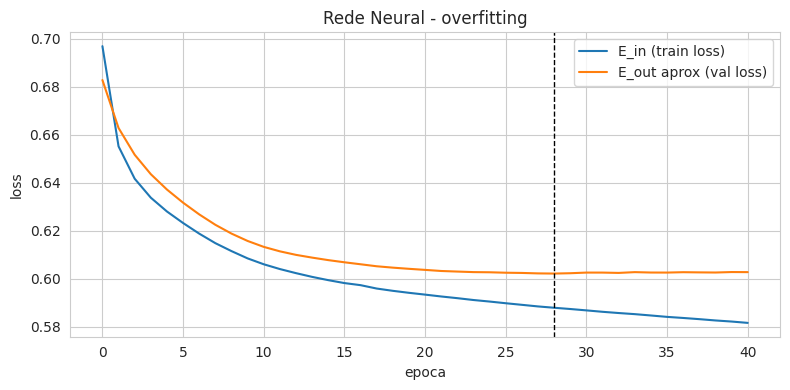

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

architecture = [X_train.shape[1], 16, 8, 1]
d_vc = sum((architecture[i] + 1) * architecture[i + 1] for i in range(len(architecture) - 1))
ratio = len(y_train) / d_vc

print("arquitetura:", architecture)
print("d_vc:", d_vc)
print("N_treino/d_vc:", round(ratio, 2))
print("regra de ouro (N >= 10*d_vc):", len(y_train) >= 10 * d_vc)

X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

nn = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
nn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
history = nn.fit(
    X_nn_train,
    y_nn_train,
    validation_data=(X_nn_val, y_nn_val),
    epochs=120,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0,
)

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print("epocas executadas:", len(history.history["loss"]))
print("melhor epoca:", best_epoch)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], label="E_in (train loss)")
ax.plot(history.history["val_loss"], label="E_out aprox (val loss)")
ax.axvline(best_epoch - 1, color="black", linestyle="--", linewidth=1)
ax.set_title("Rede Neural - overfitting")
ax.set_xlabel("epoca")
ax.set_ylabel("loss")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "nn_overfitting.png", dpi=130)
plt.show()

E_in: 0.3077 E_out: 0.3402
{'accuracy': 0.6597845601436265, 'precision': 0.663003663003663, 'recall': 0.6499102333931778, 'f1': 0.6563916591115141}


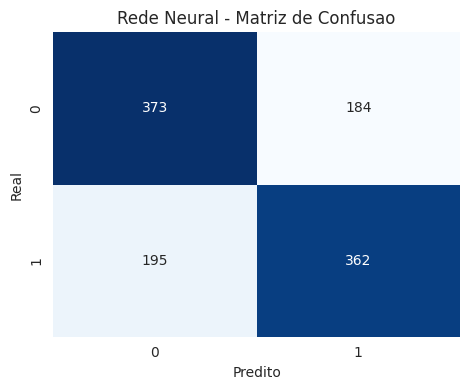

In [4]:
nn_train_pred = (nn.predict(X_train, verbose=0).ravel() >= 0.5).astype(int)
nn_test_score = nn.predict(X_test, verbose=0).ravel()
nn_test_pred = (nn_test_score >= 0.5).astype(int)
nn_ein, nn_eout = calc_ein_eout(y_train, nn_train_pred, y_test, nn_test_pred)
nn_metrics = calc_metrics(y_test, nn_test_pred)

print("E_in:", round(nn_ein, 4), "E_out:", round(nn_eout, 4))
print(nn_metrics)

plot_confusion(y_test, nn_test_pred, "Rede Neural - Matriz de Confusao", "nn_confusion.png")

nn.save(MODELS_DIR / "neural_network.keras")


## 3) Arvore de Decisao

Primeiro treinamos sem poda (para observar overfitting). Depois regularizamos `ccp_alpha` com Minimal Cost-Complexity e cross validation.

sem poda -> E_in: 0.0 E_out: 0.3932


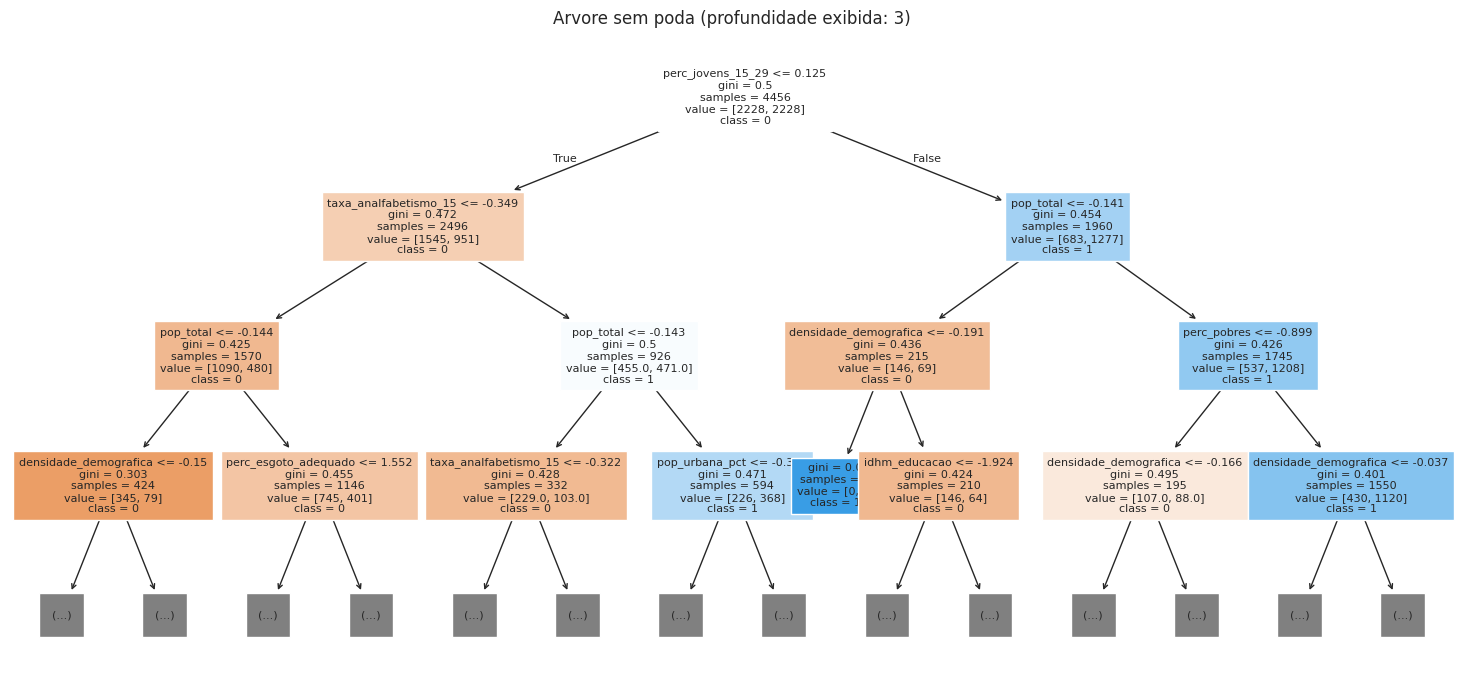

cv_folds: 10 best_alpha: 0.0025137369384127806


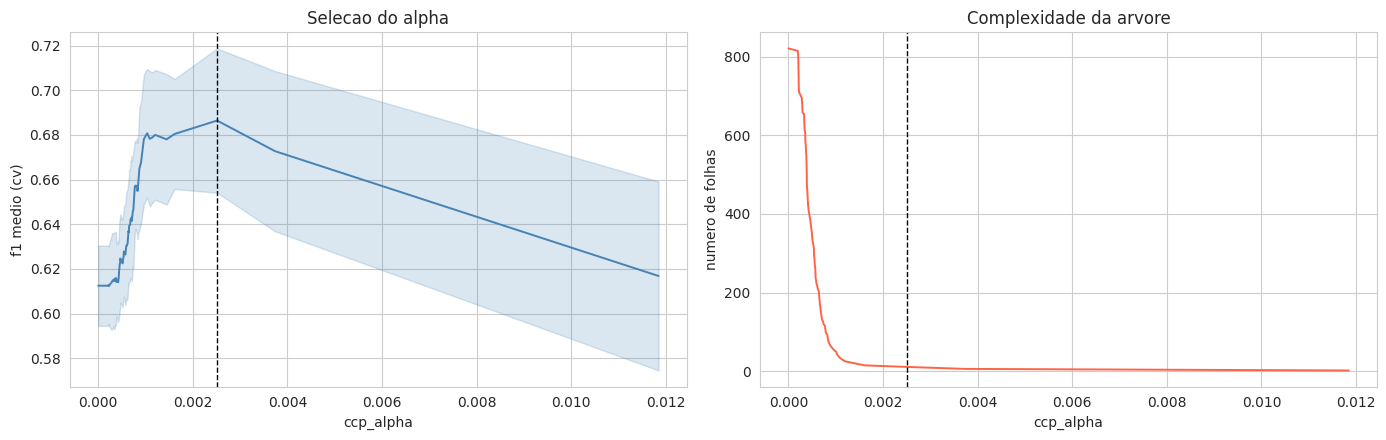

In [5]:
tree_raw = DecisionTreeClassifier(random_state=SEED)
tree_raw.fit(X_train, y_train)

tree_raw_train_pred = tree_raw.predict(X_train)
tree_raw_test_pred = tree_raw.predict(X_test)
tree_raw_ein, tree_raw_eout = calc_ein_eout(y_train, tree_raw_train_pred, y_test, tree_raw_test_pred)
print("sem poda -> E_in:", round(tree_raw_ein, 4), "E_out:", round(tree_raw_eout, 4))

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree_raw, max_depth=3, filled=True, feature_names=feature_names, class_names=["0", "1"], fontsize=8, ax=ax)
ax.set_title("Arvore sem poda (profundidade exibida: 3)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "tree_unpruned_depth3.png", dpi=130)
plt.show()

cv_folds = 10 if len(y_train) >= 2000 else 5
path = tree_raw.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]
if len(alphas) > 120:
    idx = np.linspace(0, len(alphas) - 1, 120).astype(int)
    alphas = np.unique(alphas[idx])

cv_scores = []
cv_std = []
leaf_counts = []
for alpha in alphas:
    tree_tmp = DecisionTreeClassifier(random_state=SEED, ccp_alpha=float(alpha))
    scores = cross_val_score(tree_tmp, X_train, y_train, cv=cv_folds, scoring="f1", n_jobs=-1)
    cv_scores.append(scores.mean())
    cv_std.append(scores.std())
    tree_tmp.fit(X_train, y_train)
    leaf_counts.append(tree_tmp.get_n_leaves())

best_idx = int(np.argmax(cv_scores))
best_alpha = float(alphas[best_idx])
print("cv_folds:", cv_folds, "best_alpha:", best_alpha)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(alphas, cv_scores, color="steelblue", linewidth=1.4)
ax[0].fill_between(alphas, np.array(cv_scores) - np.array(cv_std), np.array(cv_scores) + np.array(cv_std), alpha=0.2, color="steelblue")
ax[0].axvline(best_alpha, color="black", linestyle="--", linewidth=1)
ax[0].set_xlabel("ccp_alpha")
ax[0].set_ylabel("f1 medio (cv)")
ax[0].set_title("Selecao do alpha")

ax[1].plot(alphas, leaf_counts, color="tomato", linewidth=1.4)
ax[1].axvline(best_alpha, color="black", linestyle="--", linewidth=1)
ax[1].set_xlabel("ccp_alpha")
ax[1].set_ylabel("numero de folhas")
ax[1].set_title("Complexidade da arvore")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "tree_alpha_cv.png", dpi=130)
plt.show()


podada -> E_in: 0.3009 E_out: 0.342
{'accuracy': 0.6579892280071813, 'precision': 0.6527777777777778, 'recall': 0.6750448833034112, 'f1': 0.6637246248896734}


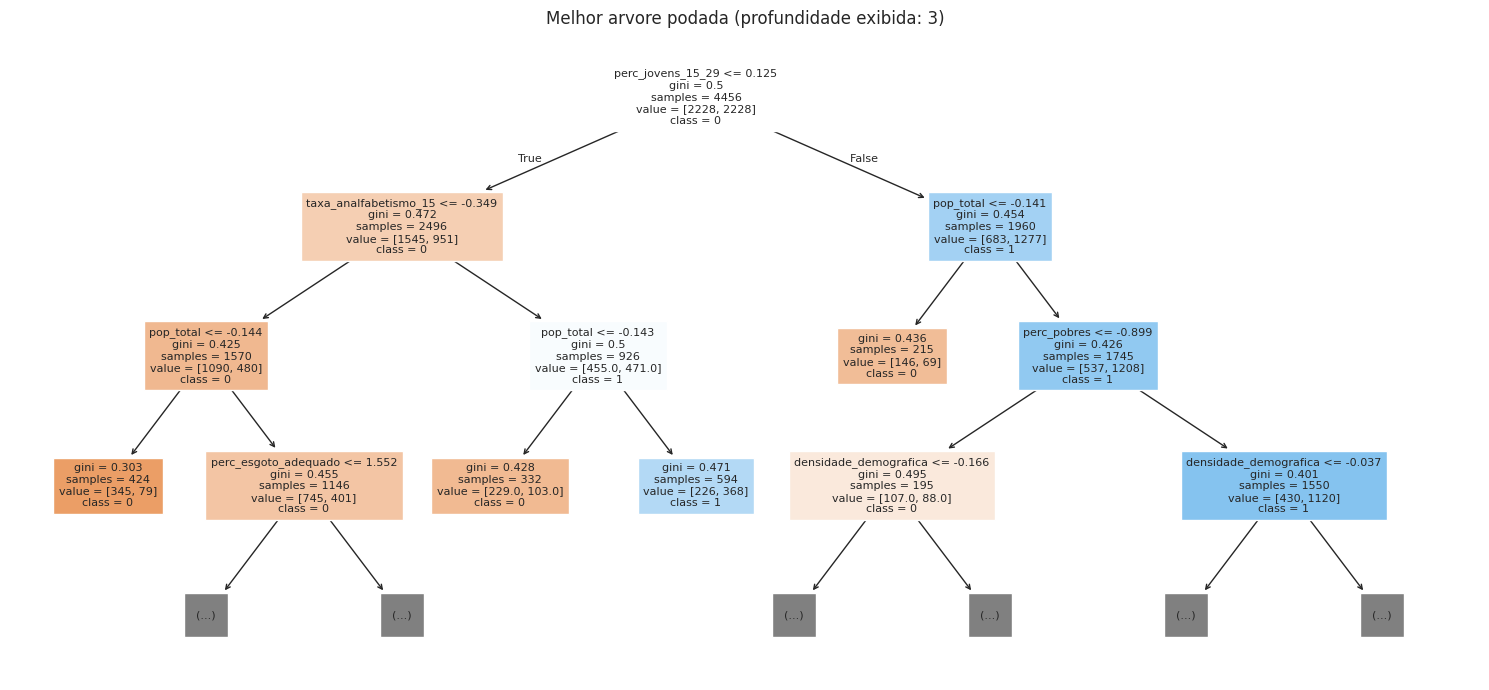

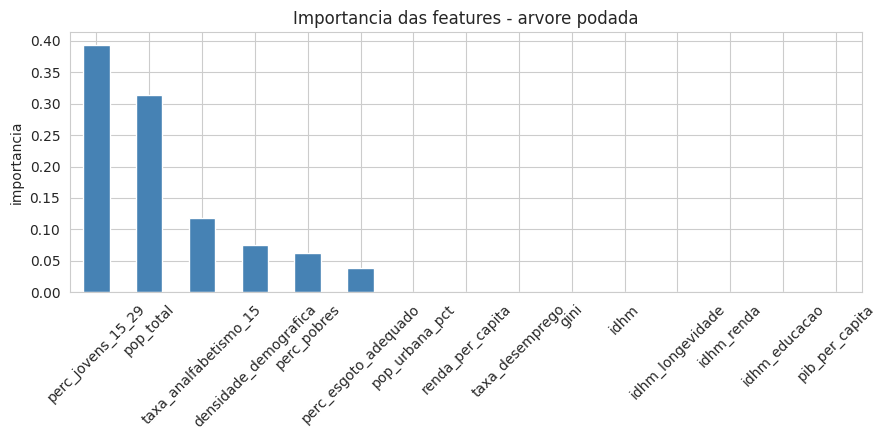

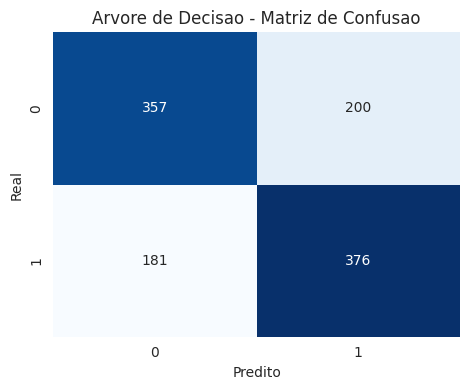

['/home/gabriel/projetos/socio_violence_predictor/models/decision_tree.joblib']

In [6]:
tree = DecisionTreeClassifier(random_state=SEED, ccp_alpha=best_alpha)
tree.fit(X_train, y_train)

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)
tree_test_score = tree.predict_proba(X_test)[:, 1]
tree_ein, tree_eout = calc_ein_eout(y_train, tree_train_pred, y_test, tree_test_pred)
tree_metrics = calc_metrics(y_test, tree_test_pred)

print("podada -> E_in:", round(tree_ein, 4), "E_out:", round(tree_eout, 4))
print(tree_metrics)

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree, max_depth=3, filled=True, feature_names=feature_names, class_names=["0", "1"], fontsize=8, ax=ax)
ax.set_title("Melhor arvore podada (profundidade exibida: 3)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "tree_pruned_depth3.png", dpi=130)
plt.show()

importances = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
importances.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Importancia das features - arvore podada")
ax.set_ylabel("importancia")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "tree_feature_importance.png", dpi=130)
plt.show()

plot_confusion(y_test, tree_test_pred, "Arvore de Decisao - Matriz de Confusao", "tree_confusion.png")

joblib.dump(tree, MODELS_DIR / "decision_tree.joblib")


## 4) SVM

Regularizacao de `C` e `gamma` por `GridSearchCV`.

melhores parametros: {'C': 100, 'gamma': 0.001}


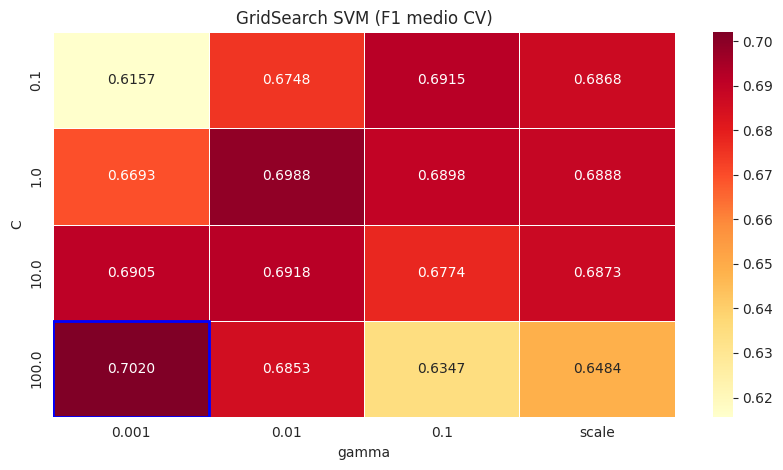

E_in: 0.3131 E_out: 0.3339 E_out_esperado: 0.7255
n_support_vectors: 3233
{'accuracy': 0.6660682226211849, 'precision': 0.6513911620294599, 'recall': 0.7145421903052065, 'f1': 0.6815068493150684}


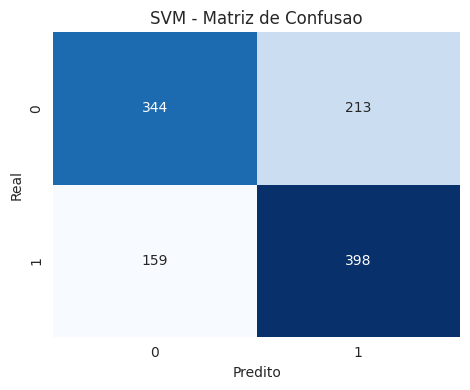

['/home/gabriel/projetos/socio_violence_predictor/models/svm.joblib']

In [7]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, "scale"],
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=cv_folds,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
svm_grid.fit(X_train, y_train)
svm = svm_grid.best_estimator_
print("melhores parametros:", svm_grid.best_params_)

grid_table = pd.DataFrame(index=param_grid["C"], columns=[str(g) for g in param_grid["gamma"]], dtype=float)
for params, score in zip(svm_grid.cv_results_["params"], svm_grid.cv_results_["mean_test_score"]):
    grid_table.loc[params["C"], str(params["gamma"])] = score

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.heatmap(grid_table.astype(float), annot=True, fmt=".4f", cmap="YlOrRd", linewidths=0.5, ax=ax)
best_c = svm_grid.best_params_["C"]
best_gamma = str(svm_grid.best_params_["gamma"])
row = list(grid_table.index).index(best_c)
col = list(grid_table.columns).index(best_gamma)
ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=False, edgecolor="blue", lw=2))
ax.set_xlabel("gamma")
ax.set_ylabel("C")
ax.set_title("GridSearch SVM (F1 medio CV)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "svm_gridsearch_heatmap.png", dpi=130)
plt.show()

svm_train_pred = svm.predict(X_train)
svm_test_pred = svm.predict(X_test)
svm_test_score = svm.decision_function(X_test)
svm_ein, svm_eout = calc_ein_eout(y_train, svm_train_pred, y_test, svm_test_pred)
svm_metrics = calc_metrics(y_test, svm_test_pred)

n_support_vectors = int(svm.n_support_.sum())
svm_expected_eout = n_support_vectors / len(y_train)

print("E_in:", round(svm_ein, 4), "E_out:", round(svm_eout, 4), "E_out_esperado:", round(svm_expected_eout, 4))
print("n_support_vectors:", n_support_vectors)
print(svm_metrics)

plot_confusion(y_test, svm_test_pred, "SVM - Matriz de Confusao", "svm_confusion.png")

joblib.dump(svm, MODELS_DIR / "svm.joblib")


## 5) Comparacao final e escolha do melhor modelo

Criterio principal: maior F1 no teste, com apoio de ROC, E_in/E_out e threshold da rede neural.


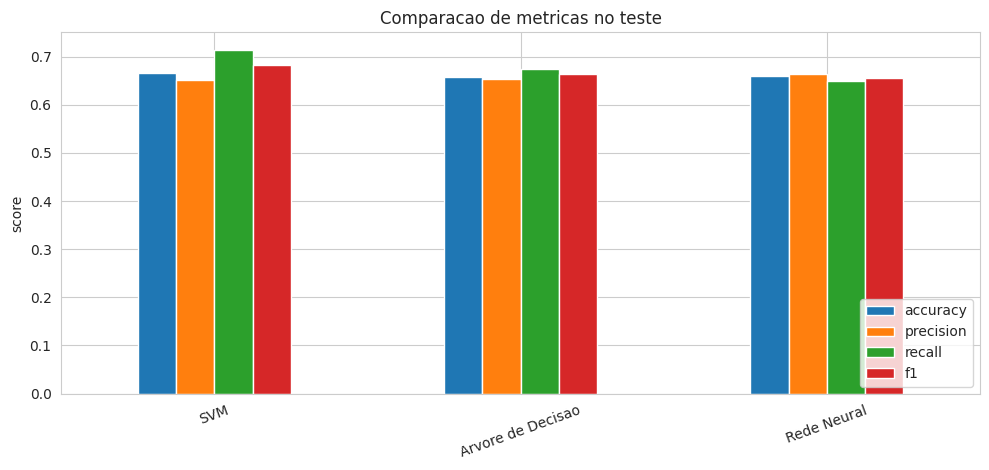

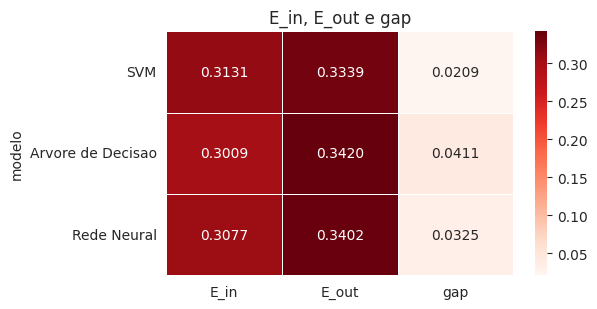

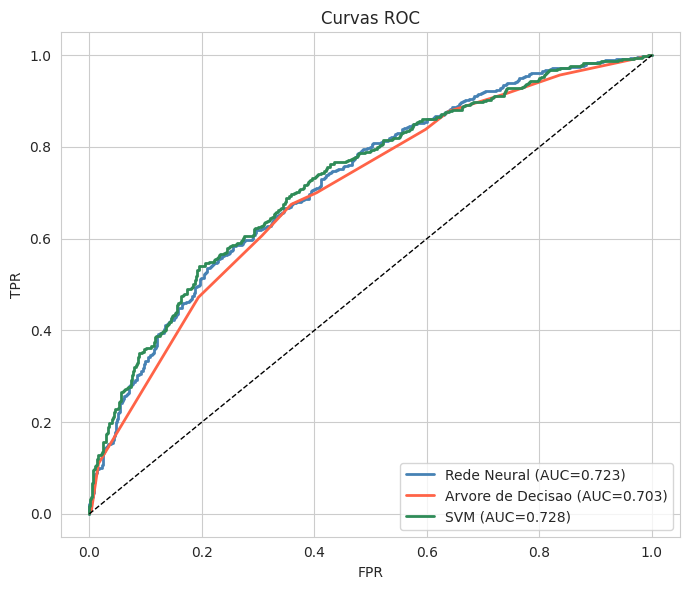

In [8]:
results = pd.DataFrame([
    {"modelo": "Rede Neural", **nn_metrics, "E_in": nn_ein, "E_out": nn_eout},
    {"modelo": "Arvore de Decisao", **tree_metrics, "E_in": tree_ein, "E_out": tree_eout},
    {"modelo": "SVM", **svm_metrics, "E_in": svm_ein, "E_out": svm_eout, "E_out_esperado": svm_expected_eout},
]).set_index("modelo")

results["gap"] = results["E_out"] - results["E_in"]
results = results.sort_values("f1", ascending=False)
results.round(4)

fig, ax = plt.subplots(figsize=(10, 4.8))
results[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_title("Comparacao de metricas no teste")
ax.set_ylabel("score")
ax.set_xlabel("")
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modelos_metricas_barras.png", dpi=130)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 3.2))
sns.heatmap(results[["E_in", "E_out", "gap"]], annot=True, fmt=".4f", cmap="Reds", linewidths=0.5, ax=ax)
ax.set_title("E_in, E_out e gap")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modelos_erros_heatmap.png", dpi=130)
plt.show()

roc_inputs = {
    "Rede Neural": nn_test_score,
    "Arvore de Decisao": tree_test_score,
    "SVM": svm_test_score,
}
colors = ["steelblue", "tomato", "seagreen"]
fig, ax = plt.subplots(figsize=(7, 6))
for (name, score), color in zip(roc_inputs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Curvas ROC")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modelos_curvas_roc.png", dpi=130)
plt.show()


Melhor modelo pelo F1 no teste: SVM


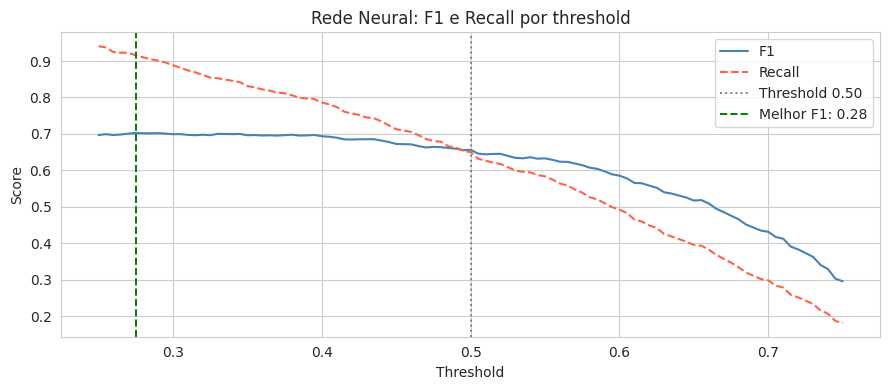

Melhor threshold da NN por F1: 0.28
F1 em 0.50: 0.6564
F1 no melhor threshold: 0.7025
Resumo salvo em data/processed/model_results.csv


In [9]:
best_model = results.index[0]
print("Melhor modelo pelo F1 no teste:", best_model)

thr_grid = np.linspace(0.25, 0.75, 101)
f1_vals = [f1_score(y_test, (nn_test_score >= t).astype(int)) for t in thr_grid]
recall_vals = [recall_score(y_test, (nn_test_score >= t).astype(int)) for t in thr_grid]
best_thr = float(thr_grid[int(np.argmax(f1_vals))])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thr_grid, f1_vals, color="steelblue", label="F1")
ax.plot(thr_grid, recall_vals, color="tomato", linestyle="--", label="Recall")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.4, label="Threshold 0.50")
ax.axvline(best_thr, color="green", linestyle="--", linewidth=1.4, label=f"Melhor F1: {best_thr:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Rede Neural: F1 e Recall por threshold")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "nn_threshold_curve.png", dpi=130)
plt.show()

print("Melhor threshold da NN por F1:", round(best_thr, 2))
print("F1 em 0.50:", round(f1_score(y_test, (nn_test_score >= 0.5).astype(int)), 4))
print("F1 no melhor threshold:", round(max(f1_vals), 4))

results.to_csv(DATA_PROCESSED / "model_results.csv")
print("Resumo salvo em data/processed/model_results.csv")
